# What explains the price of a Yu-Gi-Oh! card?

**Question (one sentence):** Using a single snapshot of the YGOPRODeck database, which observable attributes of a card — rarity, age, ban-list status, archetype, card type, and reprint history — are associated with its market price, and does ban-list status predict price once scarcity is accounted for?

**Framing.** Unit of analysis is the **card** (one row each); price is the **card-level TCGplayer** price; the spine is **explanatory** (which attributes move price, and how much) with a short **predictive coda** at the end. Snapshot pulled 2026-08-05 — this is a *cross-section*, not a time series.

> **How to read this notebook:** every scope decision is explained in the markdown *right before* the code that acts on it — that's deliberate. The `**Your read:**` cells under each chart and the model are for the analyst's interpretation. Rewrite any of this prose in your own voice; a reviewer is reading for *how the decisions were made*, not just the result.


## 0 · Setup

In [1]:
import json, datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid"); pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
DATA = "data/cardinfo_misc.json"          # cached bulk pull (misc=yes); never re-hit the API
TODAY = datetime.date(2026, 8, 6)         # snapshot date — part of the result (prices are current)

## 1 · Load the cached snapshot
We pulled the full database once with `misc=yes` and stored it locally. Card images are **not** hotlinked (the API guide blacklists that).

In [2]:
raw = json.load(open(DATA))["data"]
print(f"{len(raw):,} cards in the snapshot")

14,477 cards in the snapshot


## 2 · Decision — unit of analysis: **cards**, not printings

A card has many printings at different rarities and prices, so "the price of a card" isn't well-defined. We first leaned toward analysing **printings** (so rarity could be a per-printing driver) — but the data vetoed it: `set_price` is `$0.00` (i.e. *no recorded sale*) for **~72%** of printings, and that missingness is heaviest for cards that don't trade, which correlates with ban status — biasing the very question we care about most. So we analyse **cards**, use the well-covered card-level TCGplayer price, and bring rarity in as a *card* attribute (the highest rarity a card was printed in). Bonus: one row per card means observations are independent — no clustering needed.

In [3]:
# evidence for the reversal: how sparse is printing-level set_price?
sp = [1 for c in raw for s in (c.get("card_sets") or [])]
zero = [1 for c in raw for s in (c.get("card_sets") or []) if str(s.get("set_price")) in ("0","0.0","")]
print(f"printing-level set_price == 0 (no sale): {len(zero):,} of {len(sp):,} = {100*len(zero)/len(sp):.0f}%")

printing-level set_price == 0 (no sale): 31,321 of 44,233 = 71%


## 3 · Decision — price source: **card-level TCGplayer**
Five marketplaces are reported and they disagree hard — the dearest is >2× the cheapest on ~91% of cards (median spread ~13×, part of it a EUR-vs-USD artifact from Cardmarket). With that much disagreement, blending is meaningless; pick one and justify it. TCGplayer is the largest US market and matches our TCG focus. Note these are **asks, not transactions**.

## 4 · Decision — what `$0.00` means: **no listing → missing → drop**
Blank prices come back as `0.00`, and a Starlight Rare at `$0.00` is obviously *unlisted*, not *free*. We treat `0.00` as missing and drop it (510 cards). A real zero would poison every average and `log(0)` is undefined.

## 5 · Decision — skew: **model `log(price)`**
Mean \$1.21 vs median \$0.19; the top 1% of cards hold ~59% of all dollar value. Means describe a handful of chase cards. We log-transform so the model isn't dominated by outliers and coefficients read as approximate % effects.

## 6 · Decision — reprints: **flag, don't exclude**
68% of cards have been reprinted — excluding them would discard two-thirds of the data and skew toward newer, scarcer cards, *worsening* survivorship. Instead we keep everyone and add reprint features, so 'reprinting suppresses price' becomes a measured finding rather than a silent filter.

## 7 · Decision — ban format: **TCG**, and absence = **Unlimited**
TCG is the largest, best-documented list and matches the TCGplayer prices. Only ~2.2% of cards carry a `banlist_info` block; the other 97.8% have *no* block — that absence means *legal/Unlimited*, and it is the **control group**, not a missing value. Restricted set: Forbidden 117, Limited 94, Semi-Limited 10.

## 8 · Feature engineering
Mapping the candidate drivers onto columns. Two guardrails: **`views`/`upvotes` are excluded** from the explanatory model — they're endogenous (a card is viewed *because* it's pricey), so letting them "explain" price would be circular; they're kept only for the predictive coda. And announced-but-unreleased cards (future `tcg_date`) are dropped — no real market yet.

In [4]:
PREMIUM = ("secret","ultimate","ghost","starlight","collector","prismatic","quarter century","platinum")
def rtier(r):
    r=(r or "").lower()
    if any(k in r for k in ("ghost","starlight","ultimate")): return 5
    if any(k in r for k in ("secret","prismatic","collector","quarter century","platinum")): return 4
    if "ultra" in r: return 3
    if "super" in r: return 2
    if "rare" in r: return 1
    return 0
def price(c):
    cp=c.get("card_prices"); cp=cp[0] if isinstance(cp,list) and cp else (cp if isinstance(cp,dict) else {})
    try: return float(cp.get("tcgplayer_price"))
    except (TypeError,ValueError): return np.nan
def m(c,k):
    mi=c.get("misc_info"); return mi[0].get(k) if mi and isinstance(mi,list) else None
def d(s):
    try: return datetime.date.fromisoformat(s)
    except (TypeError,ValueError): return None
def age(x): return (TODAY-x).days/365.25 if x else np.nan

rows=[]
for c in raw:
    sets=c.get("card_sets") or []; rars=[s.get("set_rarity") for s in sets]
    tcg=d(m(c,"tcg_date")); ocg=d(m(c,"ocg_date")); fmts=m(c,"formats") or []
    t=c.get("type",""); cls="Monster" if "Monster" in t else "Spell" if "Spell" in t else "Trap" if "Trap" in t else "Other"
    rows.append(dict(card_id=c["id"], name=c["name"], price=price(c),
        num_printings=len(sets), reprinted=len(sets)>1,
        in_structure_deck=any("structure deck" in (s.get("set_name","").lower()) for s in sets),
        num_distinct_rarities=len(set(rars)), top_rarity_tier=max((rtier(r) for r in rars), default=0),
        has_premium_rarity=any(any(k in (r or "").lower() for k in PREMIUM) for r in rars),
        tcg_date=tcg, tcg_age_years=age(tcg), tcg_native=tcg is not None,
        in_ocg=("OCG" in fmts) or (ocg is not None), ocg_age_years=age(ocg),
        card_class=cls, race=c.get("race"), attribute=c.get("attribute") or "None",
        level=c.get("level"), atk=c.get("atk"), def_=c.get("def"),
        has_archetype="archetype" in c, archetype=c.get("archetype"),
        ban_tcg=(c.get("banlist_info") or {}).get("ban_tcg","Unlimited"),
        ban_ocg=(c.get("banlist_info") or {}).get("ban_ocg","Unlimited"),
        views=m(c,"views"), upvotes=m(c,"upvotes"), downvotes=m(c,"downvotes")))
df=pd.DataFrame(rows); n0=len(df)

drop_zero = df["price"].isna() | (df["price"]<=0)
future    = df["tcg_date"].apply(lambda x: bool(x) and x>TODAY)
clean = df[~drop_zero & ~future].copy()
clean["log_price"]=np.log(clean["price"])
clean.to_csv("data/cards_clean.csv", index=False)
print(f"raw {n0:,} -> dropped {int(drop_zero.sum())} zero-price, {int(future.sum())} future -> {len(clean):,} analysis rows")
clean[["name","price","log_price","num_printings","top_rarity_tier","tcg_age_years","ban_tcg"]].head()

raw 14,477 -> dropped 510 zero-price, 36 future -> 13,967 analysis rows


,name,price,log_price,num_printings,top_rarity_tier,tcg_age_years,ban_tcg
0,"""A Case for K9""",0.200,-1.609,2,5,1.016,Limited
1,"""A"" Cell Breeding Device",0.210,-1.561,1,0,19.225,Unlimited
2,"""A"" Cell Incubator",0.250,-1.386,1,0,18.727,Unlimited
3,"""A"" Cell Recombination Device",0.180,-1.715,1,0,9.755,Unlimited
4,"""A"" Cell Scatter Burst",0.180,-1.715,1,0,19.436,Unlimited


## 9 · Exploratory analysis
Four charts, each making one point. Write your interpretation in the **Your read:** cell under each — that's the part that shows you can *see* a dataset, not just plot it.

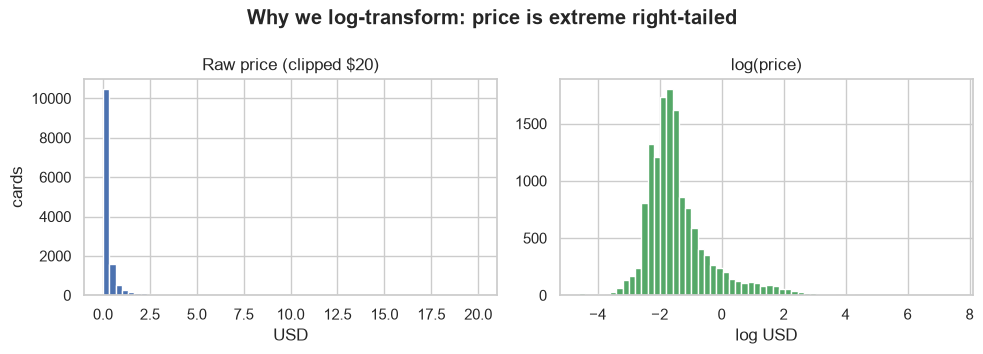

In [5]:
fig,ax=plt.subplots(1,2,figsize=(10,3.6))
ax[0].hist(clean["price"].clip(upper=20),bins=60,color="#4C72B0"); ax[0].set(title="Raw price (clipped $20)",xlabel="USD",ylabel="cards")
ax[1].hist(clean["log_price"],bins=60,color="#55A868"); ax[1].set(title="log(price)",xlabel="log USD")
fig.suptitle("Why we log-transform: price is extreme right-tailed",fontweight="bold"); fig.tight_layout()

**Your read:** Most cards are below the dollar range and very affordable. Price being right-skewed explains the bell shape of the log graph.

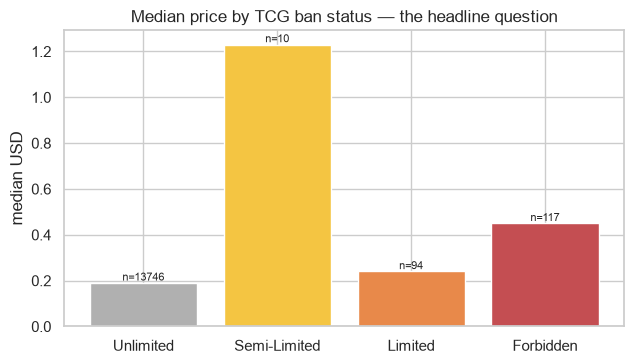

In [6]:
order=["Unlimited","Semi-Limited","Limited","Forbidden"]
med=clean.groupby("ban_tcg")["price"].median().reindex(order); cnt=clean["ban_tcg"].value_counts().reindex(order)
fig,ax=plt.subplots(figsize=(6.5,3.8)); b=ax.bar(order,med.values,color=["#B0B0B0","#F4C542","#E8894A","#C44E52"])
for bar,n in zip(b,cnt.values): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f"n={n}",ha="center",va="bottom",fontsize=8)
ax.set(title="Median price by TCG ban status — the headline question",ylabel="median USD"); fig.tight_layout()

**Your read:** Small sample size for semi-limited section does not mean much. Unlimited may be brought down by a bunch of bulk cards, and limited/forbidden is more expensive, because usually cards have to be good/iconic to fall under limited/forbidden.

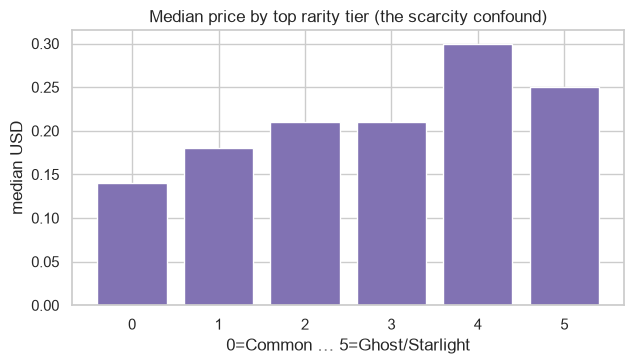

In [7]:
med=clean.groupby("top_rarity_tier")["price"].median()
fig,ax=plt.subplots(figsize=(6.5,3.8)); ax.bar(med.index.astype(str),med.values,color="#8172B3")
ax.set(title="Median price by top rarity tier (the scarcity confound)",xlabel="0=Common … 5=Ghost/Starlight",ylabel="median USD"); fig.tight_layout()

**Your read:** Secret raresd probably drive price up the most, because most people want those cards; higher rarity = smaller print run, so price partly reflects supply, not how good the card is. A Secret Rare of a bad card can outprice a Common of a great one. Name that and it goes from a fine read to a sharp one. Konami also likely prints better cards in secret rare than clower rarity.

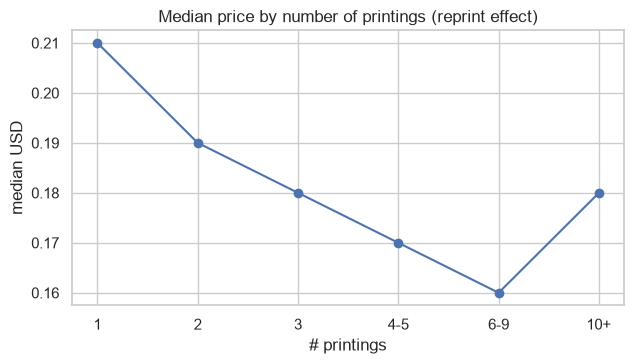

In [8]:
clean["printing_bin"]=pd.cut(clean["num_printings"],[0,1,2,3,5,10,100],labels=["1","2","3","4-5","6-9","10+"])
med=clean.groupby("printing_bin")["price"].median()
fig,ax=plt.subplots(figsize=(6.5,3.8)); ax.plot(med.index.astype(str),med.values,marker="o",color="#4C72B0")
ax.set(title="Median price by number of printings (reprint effect)",xlabel="# printings",ylabel="median USD"); fig.tight_layout()

**Your read:** Reprint has a strong inverse correlation with price, but it is hard to explain why the price trend goes up again after 10+ reprints.

## 10 · Explanatory model
OLS on `log_price` with **heteroskedasticity-robust (HC3)** standard errors. `ban_tcg` is re-leveled so **Unlimited is the baseline** — every ban coefficient then reads as "vs. a legal card." Monster-only stats (atk/def/level) are left out of this all-card model to avoid dropping every Spell/Trap; add a monster-only model below if you want them. One row per card ⇒ no clustering.

In [9]:
formula = ("log_price ~ num_printings + num_distinct_rarities + top_rarity_tier "
           "+ tcg_age_years + reprinted + in_structure_deck + has_premium_rarity "
           "+ has_archetype + in_ocg + C(card_class) + C(attribute) "
           "+ C(ban_tcg, Treatment(reference='Unlimited'))")
model = smf.ols(formula, data=clean).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     150.6
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:30:08   Log-Likelihood:                -19500.
No. Observations:               13934   AIC:                         3.904e+04
Df Residuals:                   13912   BIC:                         3.921e+04
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

/Users/ryannguyen/Downloads/TCG Market Analysis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 22, but rank is 21
  warnings.warn('covariance of constraints does not have full '


**Your read:** Rarity, reprints, age, and ban status are all strongly significant (p<0.001); rarity and reprinting matter most, and banned cards sell above unlimited ones. But the model explains only ~21% of price, so most of what sets a card's value — condition, hype, meta — isn't captured here.

## 11 · Predictive coda
How well do these features *predict* a card's (log) price out-of-sample? This is a short epilogue, not the point — it demonstrates train/test discipline without turning the piece into a Kaggle model.

In [10]:
feat_num=["num_printings","num_distinct_rarities","top_rarity_tier","tcg_age_years",
          "reprinted","in_structure_deck","has_premium_rarity","has_archetype","in_ocg"]
feat_cat=["card_class","attribute","ban_tcg"]
mdl = clean.dropna(subset=["tcg_age_years"]).copy()
X = pd.get_dummies(mdl[feat_num+feat_cat].astype({c:str for c in feat_cat}), columns=feat_cat, drop_first=True).astype(float)
y = mdl["log_price"].values
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.25,random_state=42)
lr = LinearRegression().fit(Xtr,ytr)
print(f"held-out R^2 = {r2_score(yte, lr.predict(Xte)):.3f}")
print(f"held-out RMSE (log $) = {mean_squared_error(yte, lr.predict(Xte))**0.5:.3f}")
# OPTIONAL: re-run adding np.log1p(views) to see how much the endogenous popularity signal inflates R^2.

held-out R^2 = 0.183
held-out RMSE (log $) = 0.963


**Your read:** _(how much of price is explainable from structural attributes alone? what's left unexplained, and why — condition, hype, playability the data can't see?)_

## 12 · Limitations
*The part that matters most — and where your own judgment should show. Below is a working draft grounded in what this analysis actually found; rewrite each in your own voice, cut any you disagree with, and add ones I missed.*

**Snapshot, not history — this is the hard ceiling on the headline finding.** Every price here is a single day's ask (2026‑08‑05). The ban *premium* we measured is a static association: we cannot see whether a card was cheap before it was banned and rose after, or was always expensive. The classic Yu‑Gi‑Oh! price story — a card spiking or cratering on ban‑list day — is exactly what this data structurally cannot answer.

**Correlation, not causation — and the arrow likely runs backward.** Cards are placed on the ban list *because* they are powerful and format‑defining, and that same trait drives collector demand. So "banned → +109%" almost certainly reflects an omitted variable (competitive power / iconicness) causing both the ban and the price, not the ban causing the price. The defensible claim is association net of scarcity and age, not effect.

**Asks, not transactions.** TCGplayer values are the lowest active *listing*, not a realized sale. For thin‑market cards — disproportionately the rare and banned ones central to our question — an ask may sit unmet, so part of the measured premium could be aspirational pricing rather than money that ever changes hands.

**Survivorship and selection — observed directly, not hypothetical.** We restrict to cards with an active TCGplayer listing: we dropped 510 cards priced \$0.00, and at the printing level `set_price` was missing for ~72% of printings, concentrated in cards that don't trade. The sample therefore over‑represents desirable, liquid cards — a non‑random slice of every card ever printed.

**Tiny, fragile treatment group.** Only ~221 cards are restricted in TCG, and Semi‑Limited is just 10 cards — so its eye‑catching coefficient rests on a handful of observations and should not be read as a precise magnitude. Enough to establish a direction; not enough to slice finely.

**Rarity is a supply proxy, not a quality signal.** `top_rarity_tier` is the single largest effect in the model, but rarity encodes print run, not playability — so that coefficient blends genuine scarcity with the marketing decision of how rare to make a card. "Rarity explains price" is partly scarcity explaining itself.

**~79% of price is unexplained, by construction.** R²≈0.21 means structural attributes leave four‑fifths of price variation on the table: card condition/grading, the current competitive meta, hype cycles, alternate arts, and idiosyncratic demand are all invisible here. OCG *competitive success* specifically is absent — we see OCG presence and ban status, but not tournament results, which would need a separate dataset.

**Design choices that bound the result.** Analyzing cards (not printings) flattens real per‑printing price variation; "age" is TCG debut, not recency of last reprint; and logging price + dropping zeros means we describe *cards that trade for more than \$0*, not the full catalog. Each was a defensible call (documented above), but each narrows what the answer covers.

**Endogenous signals excluded on purpose.** `views`/`upvotes` would raise R² but are caused by price and hype, so including them would let the outcome explain itself. Leaving them out is correct for an explanatory model — and it means the model deliberately ignores demand‑side information it can't treat as exogenous.


## 13 · Future work

- **Longitudinal price panel.** This analysis is a single snapshot. Collecting the same pull on a schedule would build a time series and turn the cross-sectional *what explains price* into *what moves price* — and would let the ban-list question be tested around actual ban-day events, which no snapshot can do (see Limitations).
- **Deck-planner app.** The cleaned card-level table produced here is the natural data layer for a tool to track owned/wanted cards, plan acquisitions, and surface price context — a separate project on top of this analysis.